colab에서 사용하기 위해 만든 파일.

이미 python으로 만들어 둔 상태이므로 주피터 노트북을 이용하여 파이썬 파일들을 실행할 예정.

<코드는 vscode로 수정하고 실행은 이 "Main_Colab"에서 실행하자.>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
from os.path import join
ROOT = "/content/drive"
print(ROOT)
drive.mount(ROOT, force_remount=True)

/content/drive
Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Github/Momentum_Kick_Core/

/content/drive/MyDrive/Github/Momentum_Kick_Core


In [4]:
! sudo apt-get install texlive-latex-recommended #1
! sudo apt-get install dvipng texlive-fonts-recommended #2
! wget http://mirrors.ctan.org/macros/latex/contrib/type1cm.zip #3
! unzip type1cm.zip -d /tmp/type1cm #4
! cd /tmp/type1cm/type1cm/ && sudo latex type1cm.ins  #5
! sudo mkdir /usr/share/texmf/tex/latex/type1cm #6
! sudo cp /tmp/type1cm/type1cm/type1cm.sty /usr/share/texmf/tex/latex/type1cm #7
! sudo texhash #8
! sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lmodern fonts-noto-mono fonts-urw-base35
  libfontenc1 libgs9 libgs9-common libidn12 libijs-0.35 libjbig2dec0
  libkpathsea6 libptexenc1 libsynctex2 libteckit0 libtexlua53 libtexluajit2
  libwoff1 libzzip-0-13 lmodern poppler-data t1utils tex-common texlive-base
  texlive-binaries texlive-latex-base xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  poppler-utils ghostscript fonts-japanese-mincho | fonts-ipafont-mincho
  fonts-japanese-gothic | fonts-ipafont-gothic fonts-arphic-ukai
  fonts-arphic-uming fonts-nanum debhelper gv | postscript-viewer perl-tk xpdf
  | pdf-viewer xzdec texlive-latex-base-doc texlive-latex-recommended-doc
  texlive-luatex texlive-pstricks
The following NEW packages will be installed:
  dvisvgm fonts-droid-fa

In [5]:
!python3 main_class.py

main_class.py Start
/content/drive/MyDrive/Github/Momentum_Kick_Core/main_class.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  check1 = int(np.where(dat_13TeV_multi_atlas[i]==0)[0])
calculate end : 35.162 sec
Graph, Phi correlation end : 0.000 sec
Graph, Yridge end : 0.000 sec
FrNk end : 0.000 sec
Graph, Multiplicity end : 0.000 sec
Graph, pT distribution end : 0.000 sec
Figure(7500x2000)
Graph, pp 14 prediction end : 34.775 sec
Total end : 69.937 sec


In [ ]:
!python3 Error_Graph.py

In [ ]:
import numpy as np
from scipy.optimize import minimize

def objective(x):
    return (x[0] - 1)**2 + (x[1] - 2.5)**2

def constraint(x):
    return x[0] - x[1]

def constraint_func(x):
    print(constraint(x))
    return constraint(x) - x[0] + x[1]

x0 = np.array([0, 0])  # 초기 파라미터 값

for i in range(5):
    print(f"Iteration {i+1}:")

    cons = ({'type': 'eq', 'fun': constraint_func})

    res = minimize(objective, x0, method='SLSQP', constraints=cons)

    print("Optimal parameter values:", res.x)
    print("Optimal function value:", res.fun)

    x0 = res.x  # 최적화된 파라미터 값을 다음 반복의 초기값으로 사용
    print()

Iteration 1:
0.0
0.0
0.0
1.4901161193847656e-08
-1.4901161193847656e-08
Optimal parameter values: [0. 0.]
Optimal function value: 7.25

Iteration 2:
0.0
0.0
0.0
1.4901161193847656e-08
-1.4901161193847656e-08
Optimal parameter values: [0. 0.]
Optimal function value: 7.25

Iteration 3:
0.0
0.0
0.0
1.4901161193847656e-08
-1.4901161193847656e-08
Optimal parameter values: [0. 0.]
Optimal function value: 7.25

Iteration 4:
0.0
0.0
0.0
1.4901161193847656e-08
-1.4901161193847656e-08
Optimal parameter values: [0. 0.]
Optimal function value: 7.25

Iteration 5:
0.0
0.0
0.0
1.4901161193847656e-08
-1.4901161193847656e-08
Optimal parameter values: [0. 0.]
Optimal function value: 7.25



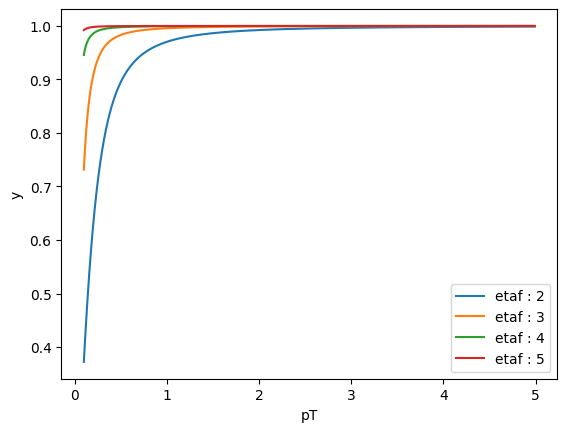

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ptf = np.arange(0.1, 5, 0.01)
m = 0.938272046
mb = 0.938272046
etaf_array = np.arange(2, 6, 1)
graph_list = []

for etaf in etaf_array:
  Energy = np.sqrt(ptf*ptf*np.cosh(etaf)*np.cosh(etaf)+m*m)
  yf = np.log((Energy+ptf*np.sinh(etaf))/(Energy-ptf*np.sinh(etaf)))/2
  graph_list.append(np.sqrt(1.-((mb*mb)/((mb*mb+ptf*ptf)*np.cosh(yf)*np.cosh(yf)))))

for graph, etaf in zip(graph_list, etaf_array):
    plt.plot(ptf, graph, label = f'etaf : {etaf}')
plt.xlabel('pT')
plt.ylabel('y')
plt.legend()
plt.show()

(1.0, 1.0, 1.0)
(1.0000000149011612, 1.0, 1.0)
(1.0, 1.0000000149011612, 1.0)
(1.0, 1.0, 1.0000000149011612)
(5.54785530749956, -0.049998329631803395, 0.02560162800540966)
(5.547855390169047, -0.049998329631803395, 0.02560162800540966)
(5.54785530749956, -0.04999832888677023, 0.02560162800540966)
(5.54785530749956, -0.049998329631803395, 0.025601628386903646)
(5.547855319819075, -0.049998333132599604, 0.025601631787553186)
(5.547855319819075, -0.049998333132599604, 0.025601631787553186)


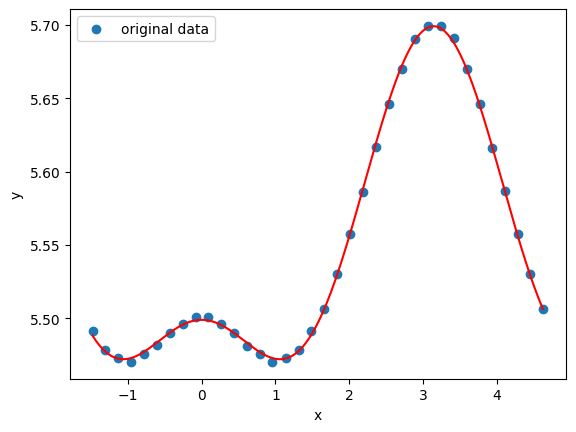

5.472241369433912


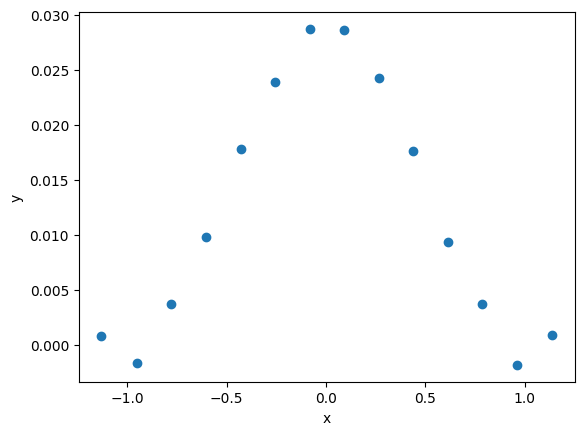

-0.00185190043391259


In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 주어진 데이터
x = np.array([-1.477700549, -1.307304388, -1.131052915, -0.953724279, -0.781618753, -0.604310125, -0.43005346, -0.259192683, -0.082514995, 0.091484337, 0.265081643, 0.436440935, 0.614138982, 0.784665094, 0.959480397, 1.138206254, 1.311860694, 1.48251668, 1.662294483, 1.836563178, 2.014185391, 2.187297442, 2.361104327, 2.53636479, 2.719898881, 2.890097494, 3.063539167, 3.237326865, 3.413049819, 3.589199018, 3.764990543, 3.932697552, 4.108032639, 4.285006833, 4.450758537, 4.630379527])
y = np.array([5.491266669, 5.478697474, 5.473037522, 5.470568252, 5.475926034, 5.481986081, 5.490038008, 5.496105678, 5.50093704, 5.500819062, 5.49643532, 5.489792922, 5.481565833, 5.475946086, 5.470389469, 5.473094576, 5.478394926, 5.491159033, 5.506305882, 5.530367223, 5.557489467, 5.586186243, 5.616495106, 5.646027191, 5.669667209, 5.690524609, 5.699192977, 5.69926376, 5.690882428, 5.670025412, 5.646300478, 5.616323369, 5.586921993, 5.557687967, 5.530078888, 5.506123056])

# Fourier Series 함수 정의
# def fourier_series(x, *a):
#     print(a)
#     result = a[0] / 2
#     for deg in range(1, len(a) // 2):
#         result += a[deg] * np.cos(deg * x) + a[deg + 1] * np.sin(deg * x)
#     return result

def fourier_series(x, *a):
    print(a)
    res = a[0]
    for deg in range(1, len(a)):
        # res += a[deg]*np.cos(deg*x) + a[deg]*np.sin(deg*x)
        res += 2*a[deg]*np.cos(deg*x)
    return res

# curve_fit 함수를 이용해 데이터를 fitting
popt, pcov = curve_fit(fourier_series, x, y, p0=[1.0]*3)
xplot = np.arange(-1.477700549, 4.630379527, 0.01)
result = fourier_series(xplot, *popt)
# print(xplot)

# 원본 데이터와 fitting 결과를 그래프로 표현
plt.scatter(x, y, label='original data')
plt.plot(xplot, result, 'r-')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

print(min(result))


x = np.array([-1.131052915, -0.953724279, -0.781618753, -0.604310125, -0.43005346, -0.259192683, -0.082514995, 0.091484337, 0.265081643, 0.436440935, 0.614138982, 0.784665094, 0.959480397, 1.138206254])
y = np.array([5.473037522, 5.470568252, 5.475926034, 5.481986081, 5.490038008, 5.496105678, 5.50093704, 5.500819062, 5.49643532, 5.489792922, 5.481565833, 5.475946086, 5.470389469, 5.473094576])

plt.clf()
plt.scatter(x, y-min(result))
plt.xlabel('x')
plt.ylabel('y')
plt.show()

print(min(y-min(result)))

아래 코드는 단순히 (특정 multiplicity) / (low multiplicity) Ratio!

[1.0, 2.6740889171124502, 5.423644073669942, 8.096552785670882, 11.459497488085127, 12.344937407626485, 15.033864915874624, 20.253326655309188]
[1.0, 1.7407407407407405, 2.444444444444444, 3.648148148148148, 5.388888888888888, 5.611111111111111, 8.055555555555554, 11.24074074074074]
[1.0, 1.813186813186813, 2.5, 3.67032967032967, 5.368131868131868, 5.525641025641025, 7.782051282051281, 10.717948717948717]
[1.0, 1.196576392245345, 1.3895326163611001, 1.5831483050785835, 1.7779642255794725, 1.9690818357282427, 2.161548634277841, 2.351233298276122]


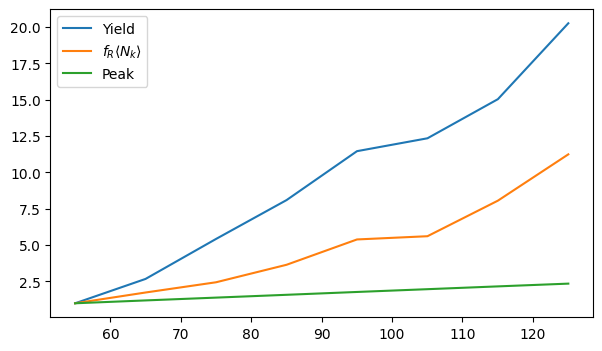

In [ ]:
import matplotlib.pyplot as plt
N = [24.94788044,34.95265487,44.96613648,54.97636434,64.98323209,75.00386421,85.03062626,95.03798167,105.0522315,115.0603414,125.0724914]
Yield = [-0.000104609,-0.000118354,0.000165537,0.002481772,0.006636479,0.013460248,0.020093798,0.02843986,0.03063732,0.037310625,0.050264139]

N_cut = [54.97636434,64.98323209,75.00386421,85.03062626,95.03798167,105.0522315,115.0603414,125.0724914]
Yield_cut = [0.002481772,0.006636479,0.013460248,0.020093798,0.02843986,0.03063732,0.037310625,0.050264139]

Peak = [2.883255591, 3.450035573, 4.006377685, 4.564621202, 5.126325294, 5.677366212, 6.232297185, 6.779206553]

# 130 이상은 Yield data가 없음.
# Nk1 : T가 mean pT에 따라서 고정
Nk1_list = [0.54, 0.94, 1.32, 1.97, 2.91, 3.03, 4.35, 6.07]

# Nk2 : q, T  모두 multiplicity에 의존 x
Nk2_list = [0.546, 0.990, 1.365, 2.004, 2.931, 3.017, 4.249, 5.852]

Yield_fin = []
Nk1_fin = []
Nk2_fin = []
Peak_fin = []
for Yield, Nk1, Nk2, peak in zip(Yield_cut, Nk1_list, Nk2_list, Peak):
  Yield_fin.append(Yield/0.002481772)
  Nk1_fin.append(Nk1/0.54)
  Nk2_fin.append(Nk2/0.546)
  Peak_fin.append(peak/2.883255591)

print(Yield_fin)
print(Nk1_fin)
print(Nk2_fin)
print(Peak_fin)

fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(7, 4)
plt.plot(N_cut, Yield_fin, label='Yield')
plt.plot(N_cut, Nk1_fin, label=r'$f_R \langle N_k \rangle$')
plt.plot(N_cut, Peak_fin, label='Peak')
plt.legend()
plt.show()

아래 코드는 특정 multiplicity 와 low multiplicity 와의 기울기 계산산

0.006636479 0.94 64.98323209
0.013460248 1.32 75.00386421
0.020093798 1.97 85.03062626
0.02843986 2.91 95.03798167
0.03063732 3.03 105.0522315
0.037310625 4.35 115.0603414
0.050264139 6.07 125.0724914
[0.041518556093638796, 0.05481700697172442, 0.058600760341014545, 0.064795407000609, 0.056225782191726706, 0.05796695675657393, 0.06816691449885648]
[0.03997254785344795, 0.03894644888593376, 0.047580606165157156, 0.05915886971006622, 0.04972455079098424, 0.06341124849633913, 0.0788916625203344]


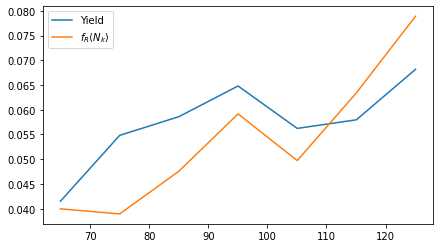

In [ ]:
import matplotlib.pyplot as plt
N_cut = [64.98323209,75.00386421,85.03062626,95.03798167,105.0522315,115.0603414,125.0724914]
Yield_cut = [0.006636479,0.013460248,0.020093798,0.02843986,0.03063732,0.037310625,0.050264139]
Nk1_list = [0.94, 1.32, 1.97, 2.91, 3.03, 4.35, 6.07]

Yield_fin = []
Nk1_fin = []

''' Yield의 기울기와 Nk의 기울기의 scale이 맞지 않아, Yield의 기울기에 100을 곱하였음.'''
for Yield, Nk1, N in zip(Yield_cut, Nk1_list, N_cut):
  print(Yield, Nk1, N)
  Yield_fin.append(100*((Yield-0.002481772)/(N-54.97636434)))
  Nk1_fin.append((Nk1-0.54)/(N-54.97636434))

print(Yield_fin)
print(Nk1_fin)

fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(7, 4)
plt.plot(N_cut, Yield_fin, label='Yield')
plt.plot(N_cut, Nk1_fin, label=r'$f_R \langle N_k \rangle$')
plt.legend()
plt.show()

위 코드에서는 fRNk와의 비교를 위해 기준을 50<Nch<60 으로 하였다.
하지만, fitting을 55부터 하기 때문에 기준을 40<Nch<50을 기준으로 기울기를 구하고 이를 multiplicity fitting에 Nk를 도입할 것이다.

그리고, 130<N_ch 는 120<Nch<130 과 동일한 Slope를 도입하였다.

In [ ]:
N = [54.97636434,64.98323209,75.00386421,85.03062626,95.03798167,105.0522315,115.0603414,125.0724914]
Yield = [0.002481772,0.006636479,0.013460248,0.020093798,0.02843986,0.03063732,0.037310625,0.050264139]

Slope1 = []


for i in range(len(Yield)):
  Slope1.append((Yield[i]-0.000165537)/(N[i]-44.96613648))

Slope1.append(Slope1[-1])
print(Slope1)

[0.00023138684077866737, 0.00032327077444578383, 0.0004426004230247412, 0.0004974045871900281, 0.0005646750762371896, 0.0005071353528608789, 0.0005299309414008545, 0.0006254010939585516, 0.0006254010939585516]


[-1.77335841e-02  2.41992551e-04  2.27230976e-06]
[[ 1.89481481e-04 -4.35852603e-06  2.35838139e-08]
 [-4.35852603e-06  1.02138182e-07 -5.60358924e-10]
 [ 2.35838139e-08 -5.60358924e-10  3.11232194e-12]]
0.00244974317419191


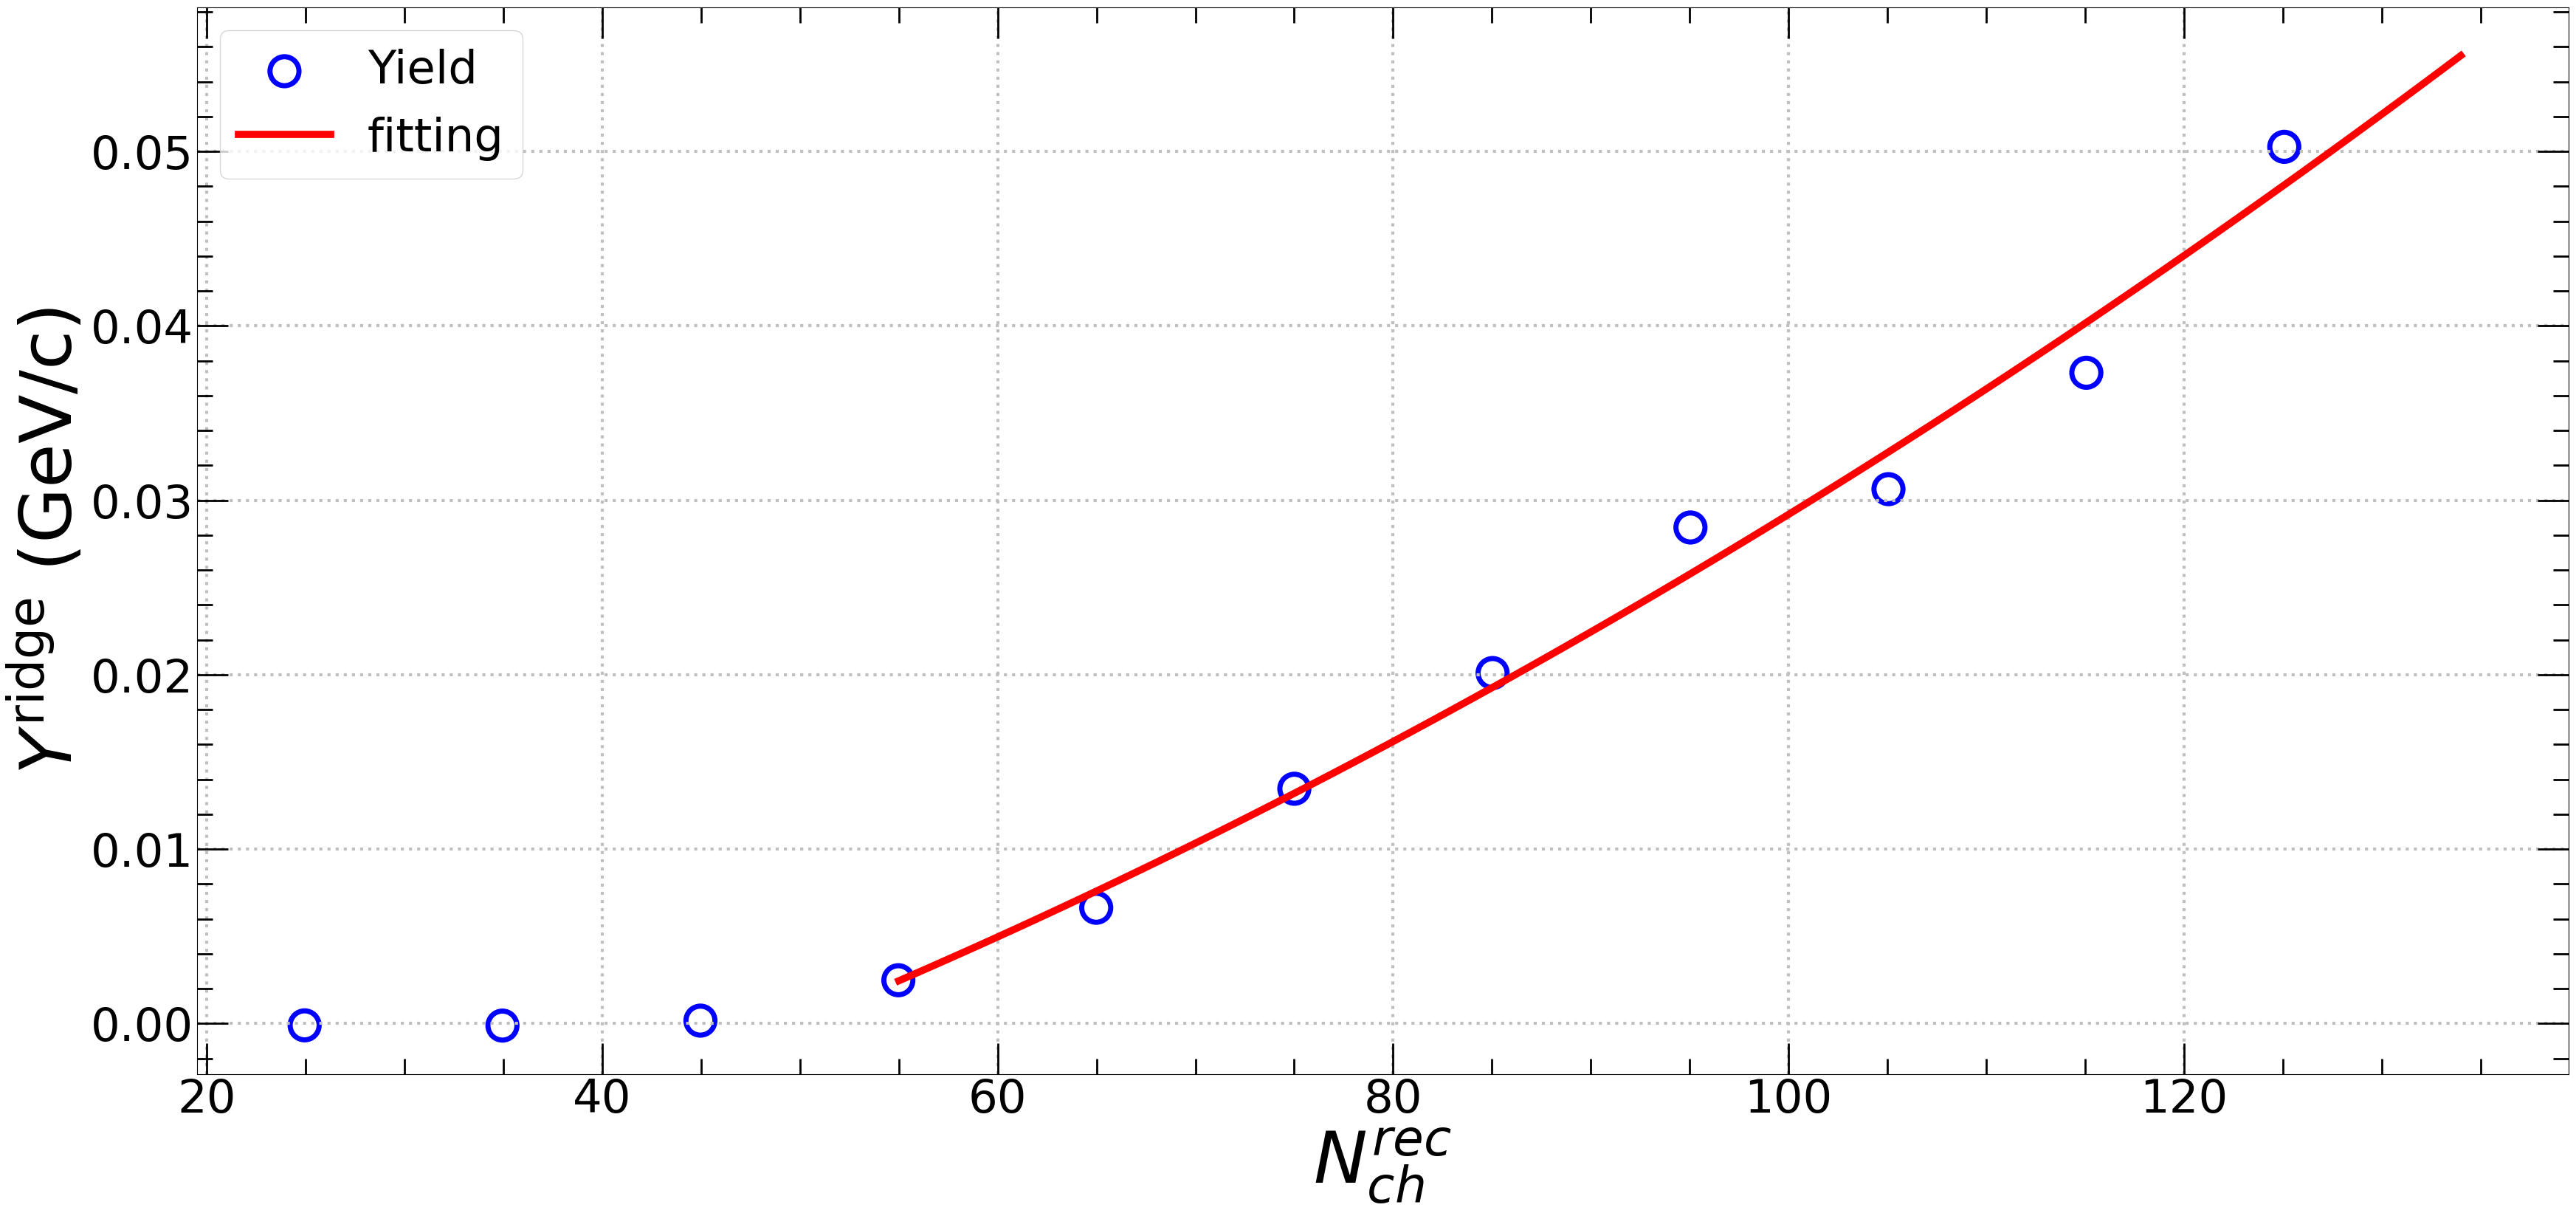

54.97636434 0.0024381169604639815
64.98323209 0.007587430073592399
75.00386421 0.013199851801829593
85.03062626 0.019272464830993104
95.03798167 0.025788896464788023
105.0522315 0.032765418687701525
115.0603414 0.04019300248004768
125.0724914 0.048079059708650285


In [ ]:
import matplotlib.pyplot as plt
import scipy
import numpy as np
from scipy.optimize import curve_fit
N = [24.94788044,34.95265487,44.96613648,54.97636434,64.98323209,75.00386421,85.03062626,95.03798167,105.0522315,115.0603414,125.0724914]
Yield = [-0.000104609,-0.000118354,0.000165537,0.002481772,0.006636479,0.013460248,0.020093798,0.02843986,0.03063732,0.037310625,0.050264139]

N_fitting = [54.97636434,64.98323209,75.00386421,85.03062626,95.03798167,105.0522315,115.0603414,125.0724914]
Yield_fitting = [0.002481772,0.006636479,0.013460248,0.020093798,0.02843986,0.03063732,0.037310625,0.050264139]

def function(x, a, b, c):
  # return a*(x-b)*(x-b)
  # return a+b*x
  return a+b*x+c*x*x
  # return a*np.exp(b*(x-c))

popt, pcov = scipy.optimize.curve_fit(function, xdata = N_fitting, ydata = Yield_fitting)
# popt, pcov = scipy.optimize.curve_fit(function, xdata = N, ydata = Yield, bounds = ((0, 0, -np.inf), (np.inf, np.inf, np.inf)))

res_x = np.arange(55, 135, 1)
# res_x = np.arange(20, 135, 1)
print(popt)
print(pcov)
print(function(55, *popt))

fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(35, 16.534, forward=True)
plt.scatter(N, Yield, label='Yield', edgecolors="blue", s=800, marker='o', facecolors='none', linewidths=5, zorder=0)
plt.plot(res_x, function(res_x, *popt), label='fitting', color = "red", linewidth=7, linestyle='-')
ax.set_xlabel(r'$N_{ch}^{rec}$', size=70)
ax.set_ylabel(r'$Y^{\mathrm{ridge}} \,\, \mathrm{(GeV/c)}$', size=70)
ax.minorticks_on()
ax.tick_params(axis='both',which='major',direction='in',width=2,length=30,labelsize=45, top = 'true', right='true')
ax.tick_params(axis='both',which='minor',direction='in',width=2,length=15,labelsize=45, top = 'true', right='true')
ax.grid(color='silver',linestyle=':',linewidth=3)
plt.legend(fontsize=45, loc='upper left')
fig.tight_layout()
plt.show()
fig.clear()

for multi in N_fitting:
  print(multi, function(multi, *popt))


In [ ]:
N_fitting = np.array(N_fitting)
residual = Yield_fitting-function(N_fitting, *popt)

fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(35, 16.534, forward=True)
plt.scatter(N_fitting, residual, label='residual', edgecolors="blue", s=800, marker='o', facecolors='none', linewidths=5, zorder=0)
ax.set_xlabel(r'$N_{ch}^{rec}$', size=70)
ax.set_ylabel('Residual', size=70)
ax.minorticks_on()
ax.tick_params(axis='both',which='major',direction='in',width=2,length=30,labelsize=45, top = 'true', right='true')
ax.tick_params(axis='both',which='minor',direction='in',width=2,length=15,labelsize=45, top = 'true', right='true')
ax.grid(color='silver',linestyle=':',linewidth=3)
# plt.legend(fontsize=45, loc='upper right')
plt.legend(fontsize=45)
fig.tight_layout()
plt.show()

fig = plt.figure()
ax = plt.axes()
fig.set_size_inches(35, 16.534, forward=True)
plt.scatter(N_fitting, (residual/Yield_fitting)*100, label='Relative Error', edgecolors="blue", s=800, marker='o', facecolors='none', linewidths=5, zorder=0)
ax.set_xlabel(r'$N_{ch}^{rec}$', size=70)
ax.set_ylabel('Relative Error', size=70)
ax.minorticks_on()
ax.tick_params(axis='both',which='major',direction='in',width=2,length=30,labelsize=45, top = 'true', right='true')
ax.tick_params(axis='both',which='minor',direction='in',width=2,length=15,labelsize=45, top = 'true', right='true')
ax.grid(color='silver',linestyle=':',linewidth=3)
# plt.legend(fontsize=45, loc='upper right')
plt.legend(fontsize=45)
fig.tight_layout()
plt.show()

NameError: name 'N_fitting' is not defined

40<$N_{ch}^{rec}$<50도 빼고 해야 하나..?

$f_R \langle N_k \rangle$에 $p_T$ 의존성을 넣은 경우와 상수인 경우만 그린 그래프!

---



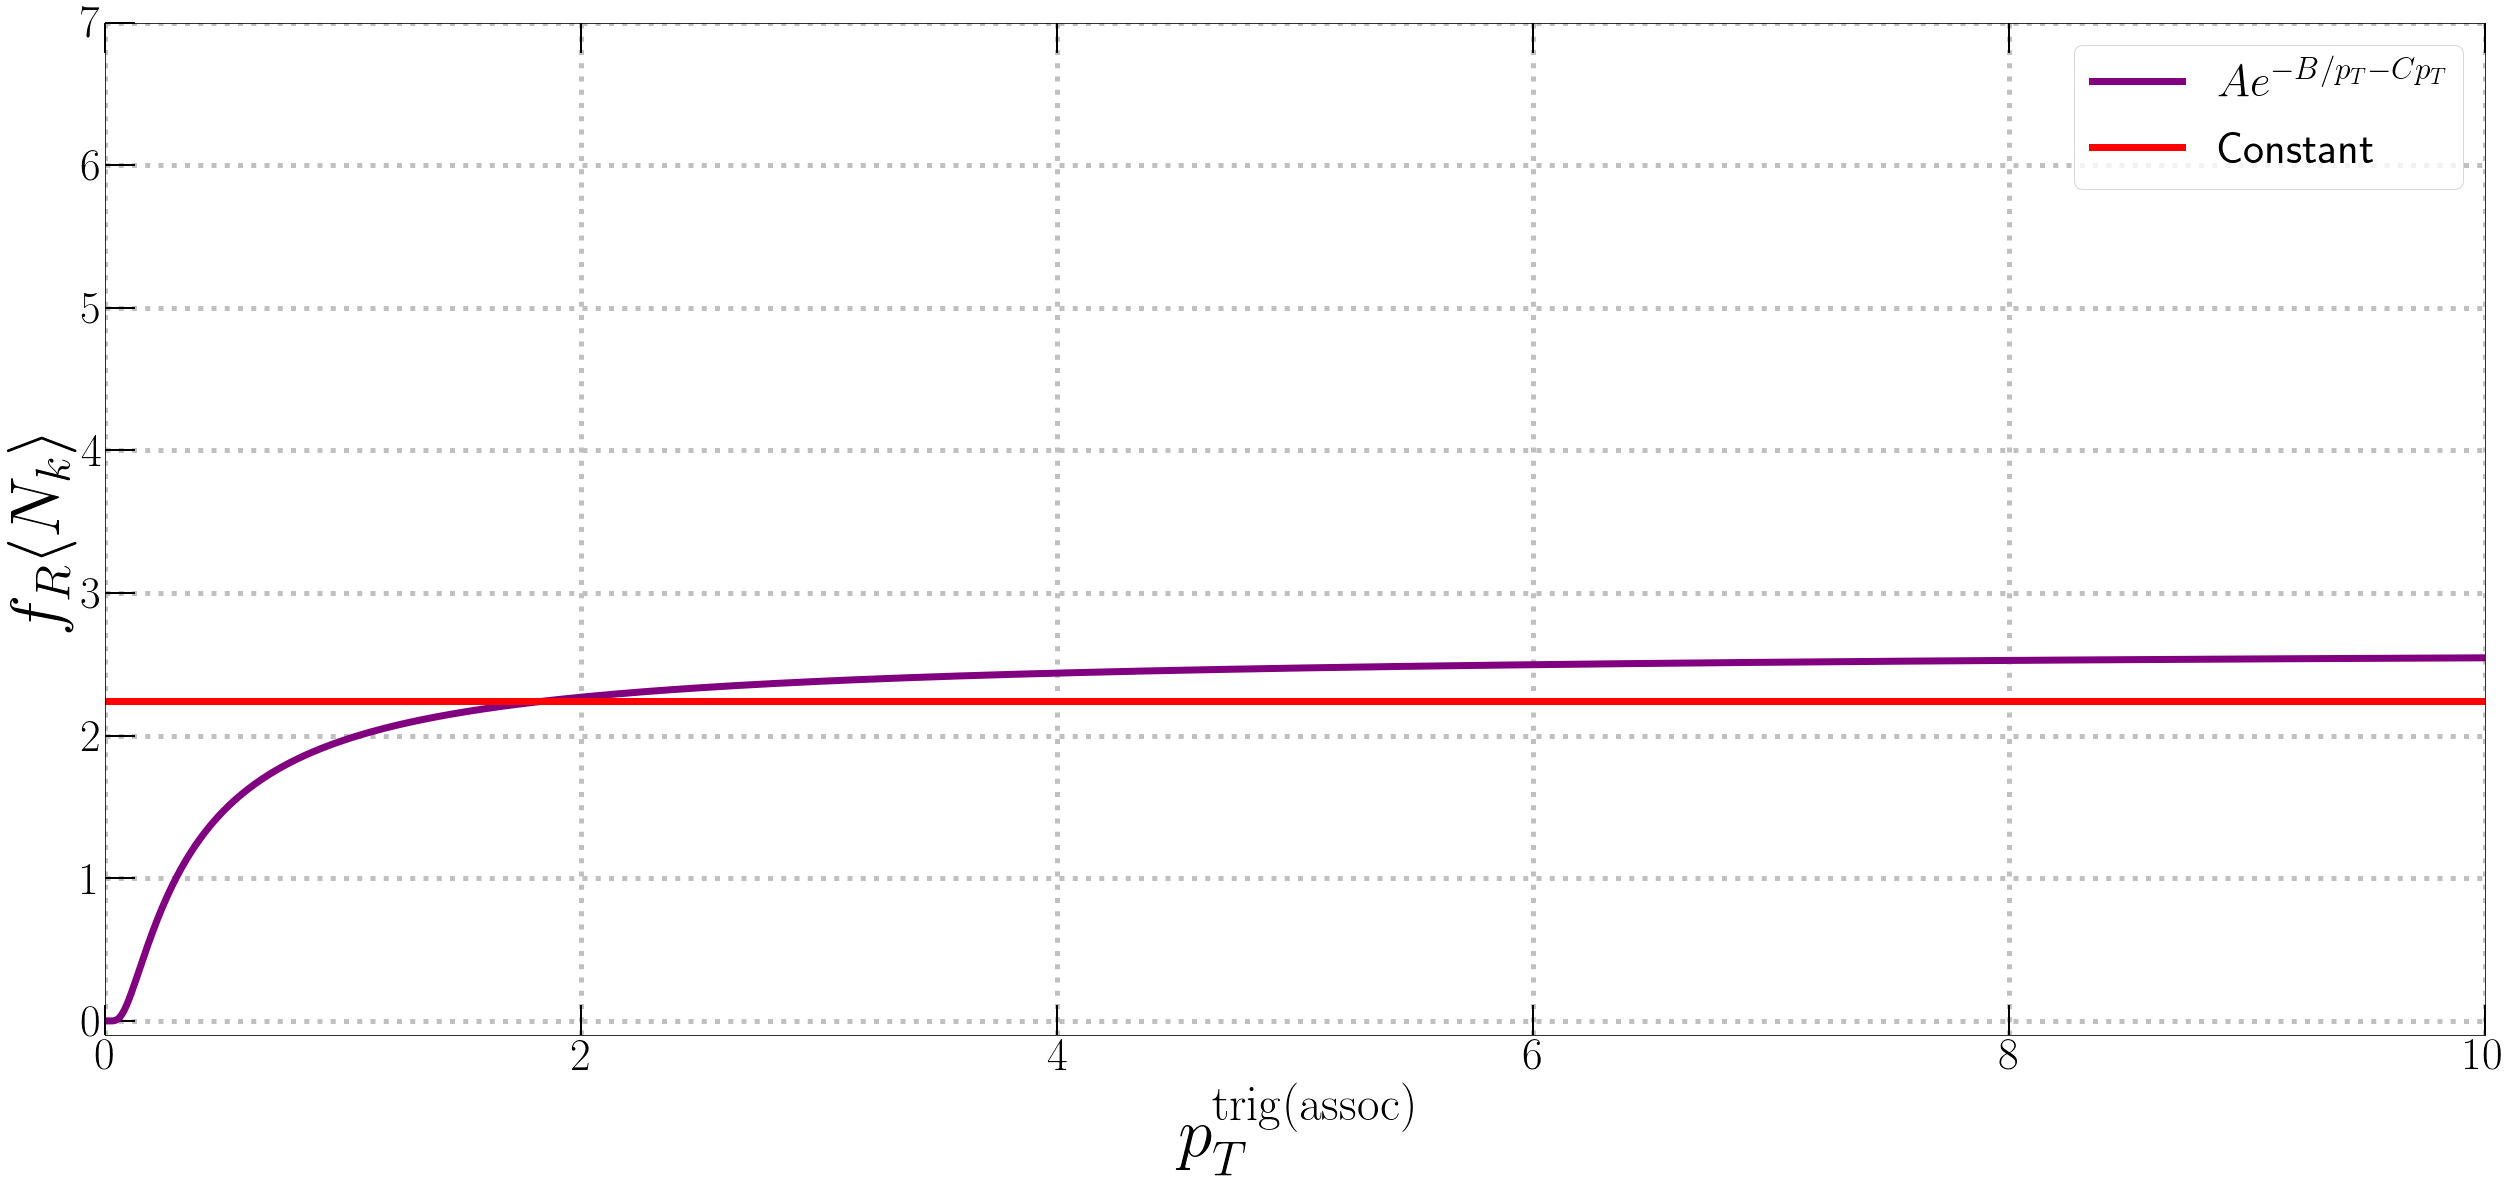

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

mpl.rcParams["text.usetex"] = True

fig3 = plt.figure()
ax = plt.axes()
fig3.set_size_inches(35, 16.534, forward=True)

def FrNk_func(pt, xx, yy, zz):
    return xx*np.exp(-yy/pt-zz*pt)


pp_13TeV_pt = [2.62, 0.287, 1e-10]
pp_13TeV_no = [2.243, 1e-10, 1e-10]


ptf = np.arange(0.01,10,0.01)

plt.plot(ptf, FrNk_func(ptf, *pp_13TeV_pt), color = 'purple', linewidth=7, label=r'$ Ae^{-B/p_T - Cp_T} $')
plt.plot(ptf, FrNk_func(ptf, *pp_13TeV_no), color = 'red', linewidth=7, label=r'Constant')


plt.xlabel(r'$p_T^{\mathrm{trig}(\mathrm{assoc})}$',size=70)
plt.ylabel(r'$f_{R} \langle N_k \rangle $',size=70)
plt.xlim(0,10)
plt.ylim(-0.1,7)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '${:g}$'.format(y)))
plt.tick_params(axis='both',which='major',direction='in',width=2,length=30,labelsize=45, top='true')
plt.tick_params(axis='both',which='minor',direction='in',width=2,length=15,labelsize=45, top='true')

plt.grid(color='silver',linestyle=':',linewidth=5, zorder=0)
plt.legend(fontsize=45)

plt.tight_layout()

plt.show()

In [ ]:
def func(a,b,x):
  return a+b*x

Const = [495.50273383, 107.49710015, 80.45872185, 81.63011884, 91.51903624, 76.75915423, 92.20455976, 110.68725956, 98.89995214]
N_fitting = [55, 65, 75, 85, 95, 105, 115, 125, 135]

for (free1,multi) in zip(Const, N_fitting):
  result = free1*func(-0.03495215, 0.00065111, multi)
  # print(result, round(result, 3))
  print(round(result, 3))

0.426
0.792
1.117
1.665
2.462
2.565
3.681
5.14
5.237


In [ ]:
temp = [100, 200, 300, 400, 500]
print(temp)
print(len(temp))
k = (4,2)
for i in k:
  print(i)
  del temp[i]

print(temp)

[100, 200, 300, 400, 500]
5
4
2
[100, 200, 400]
